**Downloading Dataset**

In [5]:
# !kaggle datasets download -d shailajakodag1/netflix-titlescsv -f netflix_titles.csv
#!/bin/bash
!kaggle datasets download shailajakodag1/netflix-titlescsv



Dataset URL: https://www.kaggle.com/datasets/shailajakodag1/netflix-titlescsv
License(s): unknown
  0%|                                               | 0.00/1.34M [00:00<?, ?B/s]
100%|██████████████████████████████████████| 1.34M/1.34M [00:00<00:00, 1.10GB/s]
Dataset URL: https://www.kaggle.com/datasets/shailajakodag1/netflix-titlescsv
License(s): unknown
  0%|                                               | 0.00/1.34M [00:00<?, ?B/s]
100%|███████████████████████████████████████| 1.34M/1.34M [00:00<00:00, 846MB/s]


**Importing All Libraries**

In [3]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
import zipfile
zip_ref = zipfile.ZipFile("/Users/badal/Practice_LIb/Netflix_title_Data_analysis/netflix-titlescsv.zip")
zip_ref.extractall() # extract file to dir 
zip_ref.close() # close file

In [4]:
df = pd.read_csv("/Users/badal/Practice_LIb/Netflix_title_Data_analysis/netflix_titles.csv")

**Data Overview**

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [14]:
df.shape

(8807, 12)

In [15]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [29]:
df.isnull().sum()
df.isna().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

**🧹 5. Data Cleaning (Important)**

In [20]:
df['director'].fillna("Unknown",inplace = True )
df['cast'].fillna("Unknown",inplace = True )
df['country'].fillna("Unknown",inplace = True )

In [46]:
# df[['director',"cast","country"]].isna().sum()
df[(df[['director', 'cast', 'country']] == "Unknown")].sum()

# df[(df[['director', 'cast', 'country']] = "Unknown")]

In [38]:
df  = df[(df[['director',"cast","country"]] != "Unknown" ).all(axis= 1)]


In [40]:
df[['director', 'cast', 'country']]


,director,cast,country
7,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin..."
8,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom
9,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States
12,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic"
24,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India
...,...,...,...
8801,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan"
8802,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States
8804,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States
8805,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States


In [43]:
df.dropna(inplace=True)

/var/folders/kd/gyl09qgj40q8r5tl10vrjht80000gn/T/ipykernel_4067/1379821321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [51]:
# Convert date column

df["date_added"] = df["date_added"] .str.strip()
df["date_added"] = pd.to_datetime(df["date_added"],format='%B %d, %Y')

/var/folders/kd/gyl09qgj40q8r5tl10vrjht80000gn/T/ipykernel_4067/913750802.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date_added"] = df["date_added"] .str.strip()
/var/folders/kd/gyl09qgj40q8r5tl10vrjht80000gn/T/ipykernel_4067/913750802.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date_added"] = pd.to_datetime(df["date_added"],format='%B %d, %Y')


In [52]:
# Making it into YYYY-MM-DD
df["date_added"] = df["date_added"].dt.strftime("%Y-%m-%d")

/var/folders/kd/gyl09qgj40q8r5tl10vrjht80000gn/T/ipykernel_4067/397305637.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date_added"] = df["date_added"].dt.strftime("%Y-%m-%d")


In [53]:
df["date_added"] 

7       2021-09-24
8       2021-09-24
9       2021-09-24
12      2021-09-23
24      2021-09-21
           ...    
8801    2016-03-09
8802    2019-11-20
8804    2019-11-01
8805    2020-01-11
8806    2019-03-02
Name: date_added, Length: 5332, dtype: object

In [55]:
df["date_added"] = pd.to_datetime(df["date_added"])

/var/folders/kd/gyl09qgj40q8r5tl10vrjht80000gn/T/ipykernel_4067/2066754708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date_added"] = pd.to_datetime(df["date_added"])


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5332 entries, 7 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5332 non-null   object        
 1   type          5332 non-null   object        
 2   title         5332 non-null   object        
 3   director      5332 non-null   object        
 4   cast          5332 non-null   object        
 5   country       5332 non-null   object        
 6   date_added    5332 non-null   datetime64[ns]
 7   release_year  5332 non-null   int64         
 8   rating        5332 non-null   object        
 9   duration      5332 non-null   object        
 10  listed_in     5332 non-null   object        
 11  description   5332 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 541.5+ KB


In [57]:
# Making new column year_added
df["year_added"] = df["date_added"].dt.year 
df["year_added"]

/var/folders/kd/gyl09qgj40q8r5tl10vrjht80000gn/T/ipykernel_4067/577020268.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year_added"] = df["date_added"].dt.year


7       2021
8       2021
9       2021
12      2021
24      2021
        ... 
8801    2016
8802    2019
8804    2019
8805    2020
8806    2019
Name: year_added, Length: 5332, dtype: int32

**Basic Analysis**

In [59]:
# Movies vs TV Shows
df['type'].value_counts()

type
Movie      5185
TV Show     147
Name: count, dtype: int64

In [60]:
# Top 10 Countries
df['country'].value_counts().head(10)

country
United States     1846
India              875
United Kingdom     183
Canada             107
Spain               91
Egypt               90
Nigeria             88
Japan               83
Turkey              79
Indonesia           76
Name: count, dtype: int64

In [64]:
# Content Added Over Time
df['year_added'].value_counts().sort_index()

year_added
2008       1
2009       2
2010       1
2011      13
2012       3
2013       7
2014      14
2015      50
2016     202
2017     724
2018    1101
2019    1265
2020    1194
2021     755
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

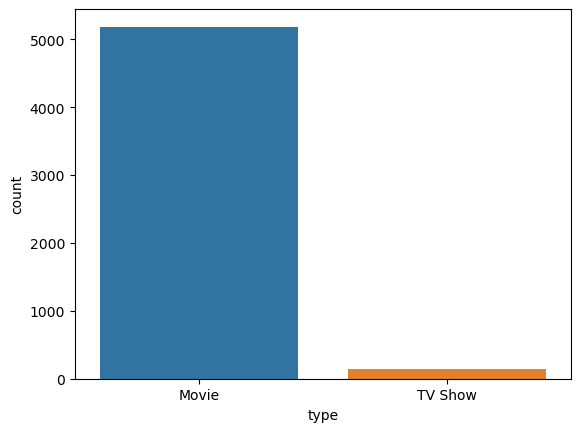

In [127]:
# Visualization
sns.countplot(data=df ,x = 'type',hue='type')


In [79]:

import ast
xs =  df['listed_in'].apply(lambda x: x.split(','))
xs

7       [Dramas,  Independent Movies,  International M...
8                         [British TV Shows,  Reality TV]
9                                     [Comedies,  Dramas]
12                        [Dramas,  International Movies]
24      [Comedies,  International Movies,  Romantic Mo...
                              ...                        
8801          [Dramas,  International Movies,  Thrillers]
8802                   [Cult Movies,  Dramas,  Thrillers]
8804                           [Comedies,  Horror Movies]
8805                [Children & Family Movies,  Comedies]
8806    [Dramas,  International Movies,  Music & Music...
Name: listed_in, Length: 5332, dtype: object

In [84]:
df['listed_in'] = list(df['listed_in'].apply(
    lambda x: x.split(', ') if isinstance(x, str) else x
))

/var/folders/kd/gyl09qgj40q8r5tl10vrjht80000gn/T/ipykernel_4067/2844655397.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['listed_in'] = list(df['listed_in'].apply(


In [89]:
df_exploaded = df.explode('listed_in')

In [118]:
df_plot = df_exploaded.groupby('listed_in',as_index=False)["listed_in"].size().sort_values(by = 'size')

In [120]:
df_plot = df_plot.head(20)

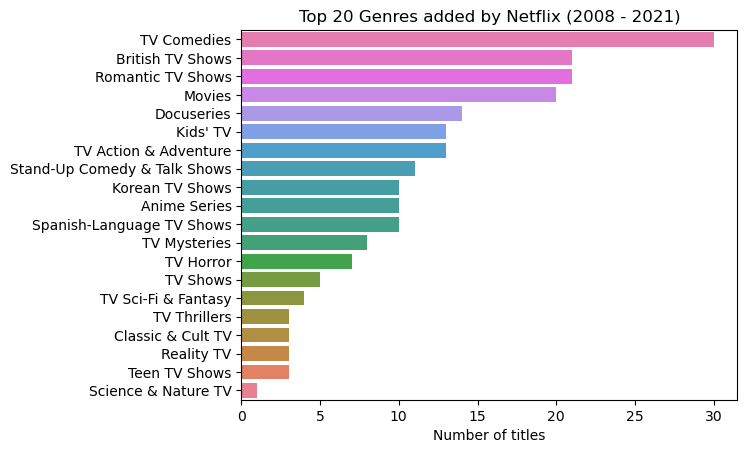

In [140]:
plt.tight_layout()
sns.barplot(data= df_plot , x='size',y='listed_in' , hue='listed_in')
plt.gca().invert_yaxis()
plt.title("Top 20 Genres added by Netflix (2008 - 2021)")
plt.xlabel("Number of titles")
plt.ylabel("")
plt.show()

In [172]:
df_plot2 = df.groupby(['year_added','type'],as_index=False).size().rename(columns={'size': 'count'}).sort_values(by = 'count')

In [176]:
df_plot2 = df_plot2.sort_values(by='year_added')
df_polt2

,year_added,type,count
0,2008,Movie,1
2,2010,Movie,1
6,2013,TV Show,1
1,2009,Movie,2
4,2012,Movie,3
9,2015,TV Show,3
5,2013,Movie,6
11,2016,TV Show,7
3,2011,Movie,13
7,2014,Movie,14


In [189]:
content_by_year = df.groupby(['year_added', 'type']).size().unstack()
content_by_year

type,Movie,TV Show
year_added,,
2008,1.0,NaN
2009,2.0,NaN
2010,1.0,NaN
2011,13.0,NaN
2012,3.0,NaN
2013,6.0,1.0
2014,14.0,NaN
2015,47.0,3.0
2016,195.0,7.0


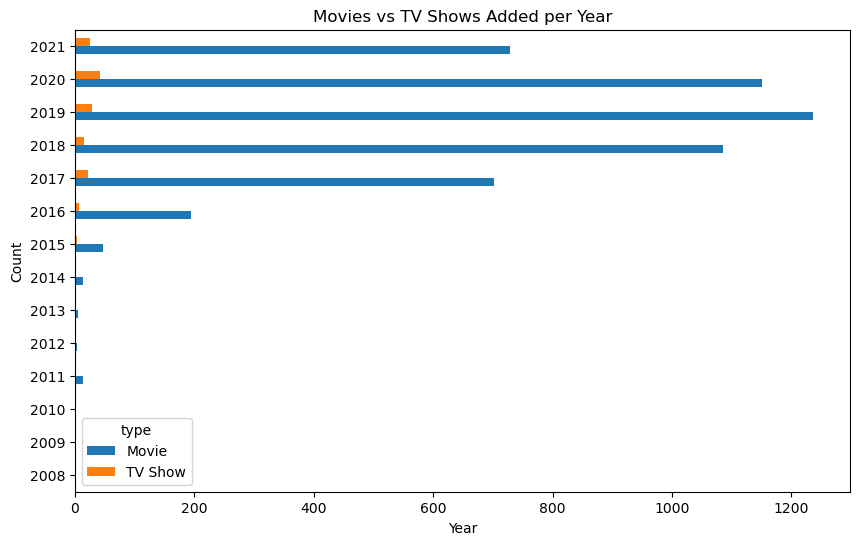

In [186]:
content_by_year.plot(kind='barh', figsize=(10,6))

plt.title("Movies vs TV Shows Added per Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

In [197]:
content_by_year_melted = content_by_year.reset_index().melt(
    id_vars='year_added',
    var_name='type',
    value_name='size'
)


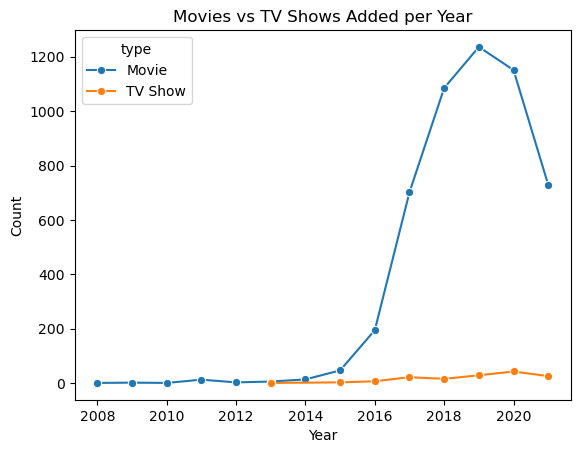

In [200]:
sns.lineplot(
    data=content_by_year_melted,
    x='year_added',
    y='size',
    hue='type',
    marker='o'
)

plt.title("Movies vs TV Shows Added per Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5332 entries, 7 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5332 non-null   object        
 1   type          5332 non-null   object        
 2   title         5332 non-null   object        
 3   director      5332 non-null   object        
 4   cast          5332 non-null   object        
 5   country       5332 non-null   object        
 6   date_added    5332 non-null   datetime64[ns]
 7   release_year  5332 non-null   int64         
 8   rating        5332 non-null   object        
 9   duration      5332 non-null   object        
 10  listed_in     5332 non-null   object        
 11  description   5332 non-null   object        
 12  year_added    5332 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(10)
memory usage: 562.4+ KB


In [203]:
df['rating'].unique()

array(['TV-MA', 'TV-14', 'PG-13', 'PG', 'R', 'TV-PG', 'G', 'TV-Y7',
       'TV-G', 'TV-Y', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [218]:
rating_of_types =df.groupby(['rating','type']).size().unstack(fill_value=0)

In [219]:
rating_of_types['TV Show'] = rating_of_types['TV Show'] .apply(lambda x : -x)
rating_of_types['TV Show'] 

rating
G            0
NC-17        0
NR           0
PG           0
PG-13        0
R            0
TV-14      -37
TV-G        -3
TV-MA      -81
TV-PG      -15
TV-Y        -5
TV-Y7       -6
TV-Y7-FV     0
UR           0
Name: TV Show, dtype: int64

In [220]:
rating_of_types['total'] = rating_of_types.sum(axis=1)
rating_of_types = rating_of_types.sort_values(by='total', ascending=False)
rating_of_types.drop(columns='total', inplace=True)

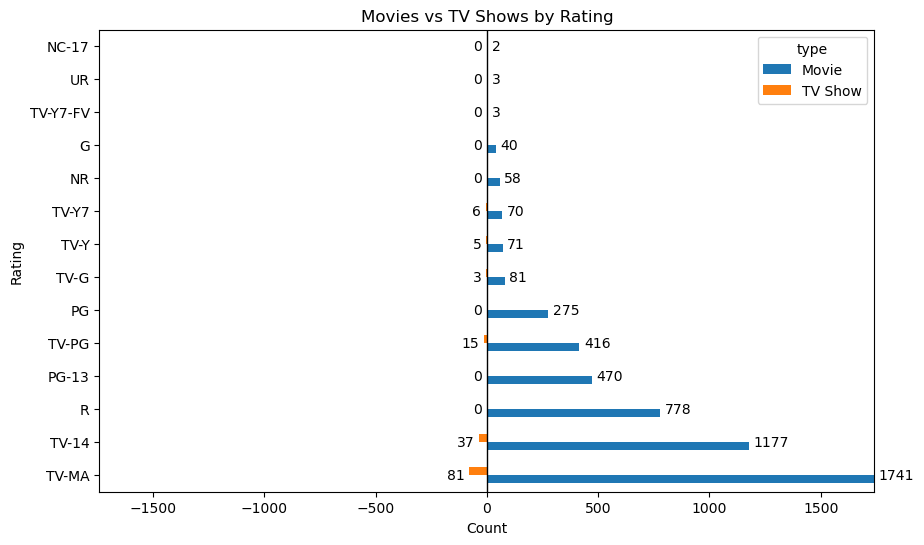

In [226]:
rating_of_types.plot(kind= "barh",figsize = (10,6))
plt.axvline(0, color='black', linewidth=1)
max_val = rating_of_types.abs().values.max()
plt.xlim(-max_val, max_val)
for i ,(index,row) in enumerate(rating_of_types.iterrows()):
    plt.text(row['Movie']+20,i,str(row['Movie']),va='center')
    plt.text(row['TV Show'] -20 ,i,str(abs(row['TV Show'])),va='center' ,ha='right')

plt.title("Movies vs TV Shows by Rating")
plt.xlabel("Count")
plt.ylabel("Rating")

plt.show()


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5332 entries, 7 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5332 non-null   object        
 1   type          5332 non-null   object        
 2   title         5332 non-null   object        
 3   director      5332 non-null   object        
 4   cast          5332 non-null   object        
 5   country       5332 non-null   object        
 6   date_added    5332 non-null   datetime64[ns]
 7   release_year  5332 non-null   int64         
 8   rating        5332 non-null   object        
 9   duration      5332 non-null   object        
 10  listed_in     5332 non-null   object        
 11  description   5332 non-null   object        
 12  year_added    5332 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(10)
memory usage: 562.4+ KB


In [231]:
df['description']

7       On a photo shoot in Ghana, an American model s...
8       A talented batch of amateur bakers face off in...
9       A woman adjusting to life after a loss contend...
12      After most of her family is murdered in a terr...
24      When the father of the man she loves insists t...
                              ...                        
8801    Recovering alcoholic Talal wakes up inside a s...
8802    A political cartoonist, a crime reporter and a...
8804    Looking to survive in a world taken over by zo...
8805    Dragged from civilian life, a former superhero...
8806    A scrappy but poor boy worms his way into a ty...
Name: description, Length: 5332, dtype: object